# **Generación de espectrogramas**

## **Librerías y módulos necesarios**

In [ ]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import pywt
from scipy.signal import butter, lfilter
import gc
import shutil
import random
import matplotlib.image as mpimg

## **Funciones y generación de imágenes**

In [ ]:
# --- Configuración ---
csv_merged = 'datos/dataaveslimpia.csv' 
carpeta_train = 'train_audio' 
carpeta_aves = 'audios_aves' 
carpeta_salida = 'espectrogramas_mel_final_TOP10'
respaldo = 'audios_no_encontrados'

SAMPLE_RATE = 32000
SEGMENT_LENGTH_SEC = 10
SEGMENT_SAMPLES = int(SEGMENT_LENGTH_SEC * SAMPLE_RATE)

os.makedirs(carpeta_salida, exist_ok=True)
os.makedirs(respaldo, exist_ok=True)

# Esto reduce el consumo de memoria al evitar la inicialización repetida de Matplotlib.
fig, ax = plt.subplots(figsize=(3, 3))
plt.axis('off')
fig.tight_layout(pad=0)
ax.set_facecolor('none')


# --- Funciones ---

def butter_bandpass_filter(data, lowcut, highcut, sr, order=5):
    data = data.astype(np.float32)
    if not np.isfinite(data).all() or len(data) == 0:
        return None
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = lfilter(b, a, data)
    return y.astype(np.float32)

def wavelet_denoising(y, wavelet='db4', level=1):
    y = y.astype(np.float32)
    if np.sum(np.square(y)) < 1e-10 or not np.isfinite(y).all():
        return y
    try:
        coeff = pywt.wavedec(y, wavelet, mode="per")
        if level > len(coeff) - 1 or level < 0 or len(coeff[-level]) == 0:
            return y
        sigma = (1/0.6745) * np.median(np.abs(coeff[-level]))
        if sigma <= 1e-6 or not np.isfinite(sigma):
            return y
        uthresh = sigma * np.sqrt(2 * np.log(len(y)))
        coeff[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeff[1:]]
        reconstructed = pywt.waverec(coeff, wavelet, mode="per").astype(np.float32)
        if not np.isfinite(reconstructed).all():
            return y
        return reconstructed
    except Exception:
        return y

def generar_espectrograma_mel(y, sr, ruta_salida, fig, ax):
    try:
        S = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=128, fmin=500, fmax=15000,
            n_fft=2048, hop_length=512
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        if not np.isfinite(S_db).all():
            print(f"[ADVERTENCIA] Espectrograma inválido: {os.path.basename(ruta_salida)}")
            return
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', cmap='magma', ax=ax)
        fig.savefig(ruta_salida, bbox_inches=None, pad_inches=0)
    finally:
        ax.clear()

# --- Construir lista de archivos disponibles ---
archivos_train = []
for root, _, files in os.walk(carpeta_train):
    for f in files:
        archivos_train.append(os.path.join(root, f))

archivos_aves = [os.path.join(carpeta_aves, f) for f in os.listdir(carpeta_aves)]

# --- Leer CSV y aplicar filtro de las 10 especies ---
df_original = pd.read_csv(csv_merged)

print("Filtrando el dataset a las 10 especies con más audios...")
especies_counts = df_original['scientific_name'].value_counts()
top_10_especies = especies_counts.head(10).index.tolist()
df = df_original[df_original['scientific_name'].isin(top_10_especies)].copy()

print(f"✅ Dataset reducido. Total audios a procesar: {len(df)} (Original: {len(df_original)})")

df['solo_nombre'] = df['filename'].apply(lambda x: os.path.basename(str(x)))
archivos_csv = set(df['solo_nombre'])

# --- Loop principal para generar espectrogramas ---
metadata_espectrogramas = []

archivos_png_existentes = set(f for f in os.listdir(carpeta_salida) if f.endswith('.png'))
print(f"Encontrados {len(archivos_png_existentes)} espectrogramas previamente generados en la carpeta TOP10.")

for _, row in tqdm(df.iterrows(), total=len(df)):
    archivo_csv = os.path.basename(row['filename'])
    nombre_cientifico = str(row.get('scientific_name', 'desconocido')).replace(" ", "_")
    base_nombre_esperado = f"{nombre_cientifico}_{archivo_csv.replace('.ogg','').replace('.wav','')}"
    
    ruta_audio = None
    coincidencias_train = [f for f in archivos_train if os.path.basename(f) == archivo_csv]
    if coincidencias_train:
        ruta_audio = coincidencias_train[0]
    elif archivo_csv in [os.path.basename(f) for f in archivos_aves]:
        ruta_audio = os.path.join(carpeta_aves, archivo_csv)
    else:
        continue

    try:
        sr_original = librosa.get_samplerate(path=ruta_audio)
        frame_length_original = int(SEGMENT_LENGTH_SEC * sr_original)
        hop_length_original = int(frame_length_original * 0.5)

        stream = librosa.stream(
            ruta_audio,
            block_length=256,
            frame_length=frame_length_original,
            hop_length=hop_length_original
        )

        segment_count = 0
        total_segments = 0
        try:
            duration = librosa.get_duration(path=ruta_audio)
            total_segments = int(duration / (SEGMENT_LENGTH_SEC * 0.5)) 
        except Exception:
            pass
        
        for y_block in stream:
            nombre_img_completo = f"{base_nombre_esperado}_segment{segment_count}.png"
            ruta_img = os.path.join(carpeta_salida, nombre_img_completo)
            
            if os.path.exists(ruta_img):
                metadata_espectrogramas.append({'filename': nombre_img_completo, 'status': 'segmento_omitido'})
                segment_count += 1
                continue

            y_resampled = librosa.resample(y=y_block.astype(np.float32), orig_sr=sr_original, target_sr=SAMPLE_RATE)
            
            if len(y_resampled) < SEGMENT_SAMPLES:
                y_resampled = np.pad(y_resampled, (0, SEGMENT_SAMPLES - len(y_resampled)), 'constant')
            else:
                y_resampled = y_resampled[:SEGMENT_SAMPLES]

            y_filtered = butter_bandpass_filter(y_resampled, lowcut=500, highcut=15000, sr=SAMPLE_RATE, order=5)
            if y_filtered is None:
                segment_count += 1
                continue

            y_denoised = wavelet_denoising(y_filtered)
            y_denoised = y_denoised / (np.max(np.abs(y_denoised)) + 1e-6)

            energia = np.sum(np.square(y_denoised))
            if energia < 0.001:
                segment_count += 1
                continue

            generar_espectrograma_mel(y_denoised, SAMPLE_RATE, ruta_img, fig, ax)

            metadata_espectrogramas.append({
                'filename': nombre_img_completo,
                'scientific_name': row.get('scientific_name', ''),
                'original_file': archivo_csv,
                'segment_index': segment_count,
                'status': 'ok'
            })
            segment_count += 1

    except Exception as e:
        print(f"❌ Error CRÍTICO procesando {archivo_csv}: {e}")
        continue

    gc.collect()

plt.close(fig)

df_metadata = pd.DataFrame(metadata_espectrogramas)
df_metadata.to_csv('metadata_espectrogramas_final_TOP10.csv', index=False)

print("✅ Proceso finalizado. Espectrogramas guardados en:", carpeta_salida)


Filtrando el dataset a las 10 especies con más audios...
✅ Dataset reducido. Total audios a procesar: 6847 (Original: 32172)
Encontrados 3511 espectrogramas previamente generados en la carpeta TOP10.


 51%|█████▏    | 3516/6847 [04:20<06:32,  8.49it/s]/home/sara/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/pywt/_thresholding.py:22: RuntimeWarning: overflow encountered in divide
  thresholded = (1 - value/magnitude)
100%|██████████| 6847/6847 [13:15<00:00,  8.60it/s]

✅ Proceso finalizado. Espectrogramas guardados en: espectrogramas_mel_final_TOP10


Se encontraron 630 espectrogramas para Coereba flaveola


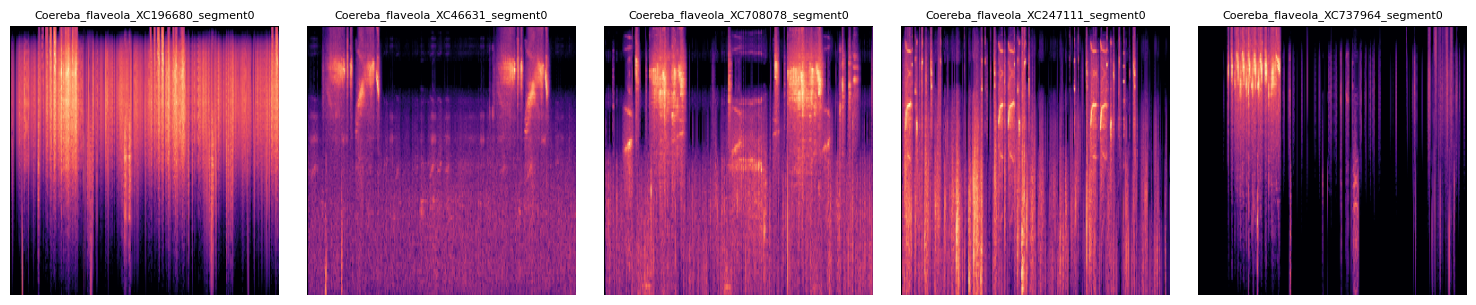

In [ ]:
def visualizar_espectrogramas_por_especie(nombre_cientifico, carpeta='espectrogramas_mel_final_TOP10', max_mostrar=5):
    nombre_cientifico = nombre_cientifico.replace(' ', '_')
    archivos = [f for f in os.listdir(carpeta) if f.startswith(nombre_cientifico) and f.endswith('.png')]

    total = len(archivos)
    print(f'Se encontraron {total} espectrogramas para {nombre_cientifico.replace("_", " ")}')

    a_mostrar = random.sample(archivos, min(max_mostrar, total))

    fig, axs = plt.subplots(1, len(a_mostrar), figsize=(3 * len(a_mostrar), 3))
    if len(a_mostrar) == 1:
        axs = [axs]  

    for ax, archivo in zip(axs, a_mostrar):
        ruta = os.path.join(carpeta, archivo)
        img = mpimg.imread(ruta)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(archivo.split('.')[0], fontsize=8)

    plt.tight_layout()
    plt.show()
    
visualizar_espectrogramas_por_especie('Coereba flaveola')
